In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


ratings = pd.read_csv("data/rating.csv")
movies = pd.read_csv("data/movie.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

ratings.head()

Ratings shape: (20000263, 4)
Movies shape: (27278, 3)


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [16]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)
avg_rating = ratings['rating'].mean()

print("Usuarios únicos:", num_users)
print("Películas:", num_movies)
print("Total ratings:", num_ratings)
print("Promedio de ratings:", round(avg_rating, 3))

Usuarios únicos: 138493
Películas: 26744
Total ratings: 20000263
Promedio de ratings: 3.526


In [17]:
# Tamaño de la matriz usuario-item
matrix_size = num_users * num_movies

# Sparsity
sparsity = 1 - (num_ratings / matrix_size)

print("Tamaño matriz usuario-item:", matrix_size)
print("Sparsity:", round(sparsity * 100, 2), "%")

Tamaño matriz usuario-item: 3703856792
Sparsity: 99.46 %


In [18]:
ratings_per_user = ratings.groupby('userId')['rating'].count()

print("Promedio ratings por usuario:", ratings_per_user.mean())
print("Mediana ratings por usuario:", ratings_per_user.median())
print("Max ratings por usuario:", ratings_per_user.max())

Promedio ratings por usuario: 144.4135299257002
Mediana ratings por usuario: 68.0
Max ratings por usuario: 9254


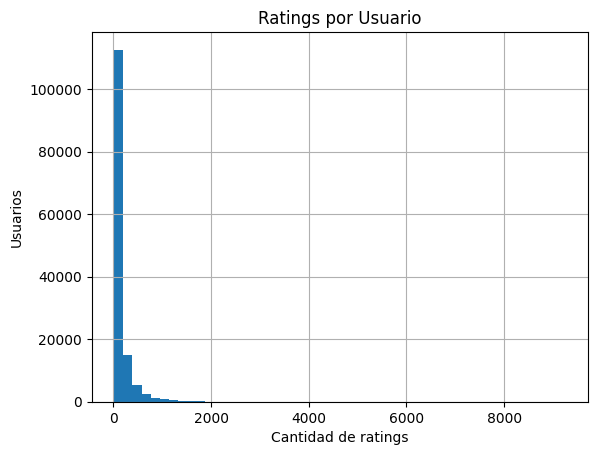

In [19]:
plt.figure()
ratings_per_user.hist(bins=50)
plt.title("Ratings por Usuario")
plt.xlabel("Cantidad de ratings")
plt.ylabel("Usuarios")
plt.show()

In [20]:
#Mas de 50 ratings
threshold = 50  

active_users = (ratings_per_user >= threshold).sum()
inactive_users = (ratings_per_user < threshold).sum()

print("Usuarios activos (>=50 ratings):", active_users)
print("Usuarios poco activos (<50 ratings):", inactive_users)

Usuarios activos (>=50 ratings): 85307
Usuarios poco activos (<50 ratings): 53186


In [21]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

print("Promedio ratings por película:", ratings_per_movie.mean())
print("Mediana ratings por película:", ratings_per_movie.median())

Promedio ratings por película: 747.8411232425965
Mediana ratings por película: 18.0


In [22]:
#top 10 de peliculas
top_movies = ratings_per_movie.sort_values(ascending=False).head(10)

top_movies = top_movies.reset_index().merge(movies, on='movieId')

top_movies[['title', 'rating']]

,title,rating
0,Pulp Fiction (1994),67310
1,Forrest Gump (1994),66172
2,"Shawshank Redemption, The (1994)",63366
3,"Silence of the Lambs, The (1991)",63299
4,Jurassic Park (1993),59715
5,Star Wars: Episode IV - A New Hope (1977),54502
6,Braveheart (1995),53769
7,Terminator 2: Judgment Day (1991),52244
8,"Matrix, The (1999)",51334
9,Schindler's List (1993),50054


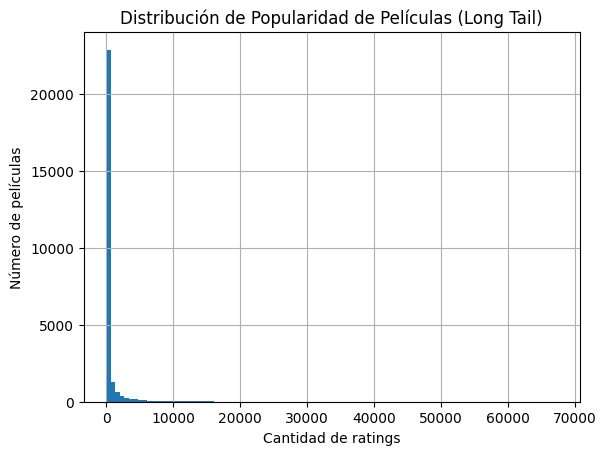

In [23]:
plt.figure()
ratings_per_movie.hist(bins=100)
plt.title("Distribución de Popularidad de Películas (Long Tail)")
plt.xlabel("Cantidad de ratings")
plt.ylabel("Número de películas")
plt.show()

In [24]:
low_popularity = (ratings_per_movie < 10).sum()
total_movies = len(ratings_per_movie)

print("Películas con <10 ratings:", low_popularity)
print("Porcentaje:", round(100 * low_popularity / total_movies, 2), "%")

Películas con <10 ratings: 11293
Porcentaje: 42.23 %
